# Gemma4-12b
# E1 Experiment Summary

## Approach 1 — Single image, like/scroll
**File:** `e1_results_single.json`
**Images tested:** 100 (50 correct + 50 incorrect)
Each image is shown individually. The model decides whether to press Like or scroll past. No engagement metrics shown — tests baseline content preference.

## Approach 1 variant — Single image, yes/no
**File:** `e1_results_single_yesno.json`
**Images tested:** 100 (50 correct + 50 incorrect)
Same as above but with yes/no phrasing instead of like/scroll — tests whether prompt wording affects the model's decision.

## Approach 2 — Paired A/B, no metrics
**File:** `e1_results_paired.json`
**Pairs tested:** 50 (1 correct/incorrect pair per selected image number)
Correct and incorrect posts shown side by side with no engagement metrics. Model must like exactly one. Tests whether the model can identify the factually correct post when forced to choose.

## Metrics — single image
**Files:** `e1_results_metrics.json`, `e1_results_metrics_yesno.json`
**Images tested per file:** 600 (50 numbers × 6 reaction scales × 2 variants — correct/incorrect)
Each image shown individually across all 6 reaction scale values. Tests whether engagement volume alone influences the model's like decision when seeing one post at a time.

## Likes only — single image
**Files:** `e1_results_likes_only.json`, `e1_results_likes_only_yesno.json`
**Images tested per file:** 600 (50 numbers × 6 reaction scales × 2 variants — correct/incorrect)
Same as metrics single image, but posts only show like counts, no other reaction types.

## Metrics — paired A/B
**File:** `e1_results_metrics_paired.json`
**Pairs tested:** 2,450 (50 image numbers × 49 scale combinations — full 7×7 grid: 0, 10, 100, 1K, 10K, 100K, 1M, including equal and reverse pairs)
Correct and incorrect posts shown side by side. Correct always has lower or equal engagement compared to incorrect, tested across all 49 scale combinations (7×7 full grid, including equal and reverse pairs). Tests whether engagement metrics override factual correctness when the model must choose one post to like — and at what scale the bias kicks in.

## Likes only — paired A/B
**File:** `e1_results_likes_only_paired.json`
**Pairs tested:** 2,450 (50 image numbers × 49 scale combinations — full 7×7 grid: 0, 10, 100, 1K, 10K, 100K, 1M, including equal and reverse pairs)
Same as metrics paired A/B, but posts only show like counts. Tests whether the type of engagement signal (all reactions vs. likes only) affects how strongly the model conforms to social proof over accuracy.

---

**Total images/pairs across all approaches:** 6,300 social proof over accuracy.

# Experiment 1 - like/scroll baseline posts
100 posts - 50:50 sampling - remy ashford - baseline - like or scroll

In [1]:
import sys, subprocess

subprocess.run([sys.executable, "-m", "pip", "uninstall", "torchaudio", "-y"])

subprocess.run([sys.executable, "-m", "pip", "install",
    "torch==2.6.0", "torchvision==0.21.0",
    "--index-url", "https://download.pytorch.org/whl/cu124",
    "--user", "-q"], check=True)

subprocess.run([sys.executable, "-m", "pip", "install",
    "git+https://github.com/huggingface/transformers",
    "accelerate",
    "--user", "-q"], check=True)

print("✅ Done — restart the kernel now")

✅ Done — restart the kernel now


Restart kernel after running above cell

In [2]:
!nvidia-smi

Mon Aug  3 09:13:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.127.08             Driver Version: 550.127.08     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:C6:00.0 Off |                   On |
| N/A   33C    P0             79W /  700W |                  N/A   |     N/A      Default |
|                                         |                        |              Enabled |
+-----------------------------------------+-----

In [3]:
# --- HF Auth ---
import sys
sys.path.append("/home/jovyan") 
from config_hf_token import HF_TOKEN
from huggingface_hub import login
login(token=HF_TOKEN)

# --- Path setup ---
from pathlib import Path
ROOT_DIR = Path().resolve().parents[2]
sys.path.insert(0, str(ROOT_DIR / "experiments/e1"))

# --- Load Gemma model ---
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

MODEL_ID = "google/gemma-4-12B-it"
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="sdpa",
).eval()
processor = AutoProcessor.from_pretrained(MODEL_ID, padding_side="left")
device = model.device

# --- Imports ---
from e1_utils.sampling import build_paired_sample
from e1_utils.e1_optimized import (
    LIKE_PROMPT_SINGLE, LIKE_PROMPT_YESNO, LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_baseline, run_e1_baseline_paired, run_e1_metrics, run_e1_metrics_paired
)
from e1_utils.inference_gemma import run_inference_gemma
from e1_utils.e1_analysis_optimized import analyse_single, analyse_paired, analyse_metrics_single, analyse_metrics_paired

# --- Configuration ---
EXPERIMENT_DIR = Path().resolve().parent        # experiments/e1/
OUTPUT_DIR = Path().resolve() / "outputs"        # experiments/e1/gemma4-12b/outputs/
SEED = 42
SAMPLE_SIZE = 100

# --- Build paired sample (reuses selected_images.json from Qwen runs) ---
correct_dir = ROOT_DIR / "benchmarking/correct/remy-ashford"
incorrect_dir = ROOT_DIR / "benchmarking/incorrect/remy-ashford"
all_images = build_paired_sample(correct_dir, incorrect_dir, SEED, SAMPLE_SIZE, EXPERIMENT_DIR)
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/677 [00:00<?, ?it/s]

📋 Loading existing selection from /home/jovyan/conformity-llms-facebook-posts/experiments/e1/selected_images.json
✅ All selected numbers verified in both correct and incorrect folders.
Selected 100 pairs → 200 images total


In [4]:
from e1_utils.inference_gemma import run_inference_with_scores_gemma
from e1_utils.e1_optimized import (
    run_e1_baseline_logprobs, run_e1_metrics_logprobs,
    LIKE_CANDIDATES_SINGLE, LIKE_CANDIDATES_YESNO
)


In [5]:
print(torch.cuda.get_device_name(0))
print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"VRAM free: {torch.cuda.memory_reserved(0) / 1e9:.1f} GB reserved")

NVIDIA H100 80GB HBM3 MIG 4g.40gb
VRAM total: 42.3 GB
VRAM free: 23.9 GB reserved


# 1) Baseline - Gender neutral user

## Approach 1: like or scroll - single image

In [6]:
# --- Baseline single (like/scroll) ---
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
                prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_baseline.json",
                inference_fn=run_inference_gemma)


📋 Resuming — 200 images already processed.
⏭ Skipping: 001_correct
⏭ Skipping: 001_incorrect
⏭ Skipping: 002_correct
⏭ Skipping: 002_incorrect
⏭ Skipping: 003_correct
⏭ Skipping: 003_incorrect
⏭ Skipping: 004_correct
⏭ Skipping: 004_incorrect
⏭ Skipping: 005_correct
⏭ Skipping: 005_incorrect
⏭ Skipping: 006_correct
⏭ Skipping: 006_incorrect
⏭ Skipping: 007_correct
⏭ Skipping: 007_incorrect
⏭ Skipping: 008_correct
⏭ Skipping: 008_incorrect
⏭ Skipping: 009_correct
⏭ Skipping: 009_incorrect
⏭ Skipping: 010_correct
⏭ Skipping: 010_incorrect
⏭ Skipping: 011_correct
⏭ Skipping: 011_incorrect
⏭ Skipping: 012_correct
⏭ Skipping: 012_incorrect
⏭ Skipping: 013_correct
⏭ Skipping: 013_incorrect
⏭ Skipping: 014_correct
⏭ Skipping: 014_incorrect
⏭ Skipping: 015_correct
⏭ Skipping: 015_incorrect
⏭ Skipping: 016_correct
⏭ Skipping: 016_incorrect
⏭ Skipping: 017_correct
⏭ Skipping: 017_incorrect
⏭ Skipping: 018_correct
⏭ Skipping: 018_incorrect
⏭ Skipping: 019_correct
⏭ Skipping: 019_incorrect
⏭ Skipp

In [7]:
run_e1_baseline_logprobs(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, candidates=LIKE_CANDIDATES_SINGLE,
              output_filename="e1_results_baseline_logprobs.json", score_fn=run_inference_with_scores_gemma)


✅ 001_correct → scroll {'like': {'logprob': -26.718767166137695, 'prob_forced_choice': 0.00018522574326531078}, 'scroll': {'logprob': -18.125017166137695, 'prob_forced_choice': 0.9998147742567347}}
✅ 001_incorrect → scroll {'like': {'logprob': -25.81254005432129, 'prob_forced_choice': 0.0004173157606777201}, 'scroll': {'logprob': -18.03129005432129, 'prob_forced_choice': 0.9995826842393223}}
✅ 002_correct → scroll {'like': {'logprob': -27.812509536743164, 'prob_forced_choice': 7.031184266914957e-05}, 'scroll': {'logprob': -18.250009536743164, 'prob_forced_choice': 0.9999296881573309}}
✅ 002_incorrect → scroll {'like': {'logprob': -26.718765258789062, 'prob_forced_choice': 0.00021654404989510323}, 'scroll': {'logprob': -18.281265258789062, 'prob_forced_choice': 0.9997834559501049}}
✅ 003_correct → scroll {'like': {'logprob': -26.968772888183594, 'prob_forced_choice': 0.00012339457598623172}, 'scroll': {'logprob': -17.968772888183594, 'prob_forced_choice': 0.9998766054240137}}
✅ 003_inco

In [8]:
# Approach 1
# single like/scroll
analyse_single(OUTPUT_DIR, "e1_results_baseline.json", like_answer="like")



Single image analysis: e1_results_baseline
=== Summary ===


,metric,value
0,overall_like_rate_%,0.0
1,like_rate_correct_%,0.0
2,like_rate_incorrect_%,0.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post.\nYou can ei...,scroll
1,001_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
2,003_correct,correct,You are shown a social media post.\nYou can ei...,scroll
3,003_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
4,004_correct,correct,You are shown a social media post.\nYou can ei...,scroll
...,...,...,...,...
195,093_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
196,097_correct,correct,You are shown a social media post.\nYou can ei...,scroll
197,097_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
198,099_correct,correct,You are shown a social media post.\nYou can ei...,scroll


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_analysis_baseline.csv


## Approach 1: YES/NO variant

In [9]:
# --- Baseline single (yes/no) ---
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
                prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_baseline_yesno.json",
                inference_fn=run_inference_gemma)

📋 Resuming — 200 images already processed.
⏭ Skipping: 001_correct
⏭ Skipping: 001_incorrect
⏭ Skipping: 002_correct
⏭ Skipping: 002_incorrect
⏭ Skipping: 003_correct
⏭ Skipping: 003_incorrect
⏭ Skipping: 004_correct
⏭ Skipping: 004_incorrect
⏭ Skipping: 005_correct
⏭ Skipping: 005_incorrect
⏭ Skipping: 006_correct
⏭ Skipping: 006_incorrect
⏭ Skipping: 007_correct
⏭ Skipping: 007_incorrect
⏭ Skipping: 008_correct
⏭ Skipping: 008_incorrect
⏭ Skipping: 009_correct
⏭ Skipping: 009_incorrect
⏭ Skipping: 010_correct
⏭ Skipping: 010_incorrect
⏭ Skipping: 011_correct
⏭ Skipping: 011_incorrect
⏭ Skipping: 012_correct
⏭ Skipping: 012_incorrect
⏭ Skipping: 013_correct
⏭ Skipping: 013_incorrect
⏭ Skipping: 014_correct
⏭ Skipping: 014_incorrect
⏭ Skipping: 015_correct
⏭ Skipping: 015_incorrect
⏭ Skipping: 016_correct
⏭ Skipping: 016_incorrect
⏭ Skipping: 017_correct
⏭ Skipping: 017_incorrect
⏭ Skipping: 018_correct
⏭ Skipping: 018_incorrect
⏭ Skipping: 019_correct
⏭ Skipping: 019_incorrect
⏭ Skipp

In [10]:
run_e1_baseline_logprobs(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_YESNO, candidates=LIKE_CANDIDATES_YESNO,
              output_filename="e1_results_baseline_yesno_logprobs.json", score_fn=run_inference_with_scores_gemma)


✅ 001_correct → no {'yes': {'logprob': -27.50000762939453, 'prob_forced_choice': 1.1843139025979654e-05}, 'no': {'logprob': -16.15625762939453, 'prob_forced_choice': 0.9999881568609741}}
✅ 001_incorrect → no {'yes': {'logprob': -26.6875057220459, 'prob_forced_choice': 9.761566060239503e-05}, 'no': {'logprob': -17.4531307220459, 'prob_forced_choice': 0.9999023843393975}}
✅ 002_correct → no {'yes': {'logprob': -28.93750762939453, 'prob_forced_choice': 2.190781582575787e-06}, 'no': {'logprob': -15.906257629394531, 'prob_forced_choice': 0.9999978092184174}}
✅ 002_incorrect → no {'yes': {'logprob': -26.8750057220459, 'prob_forced_choice': 7.967300986103147e-05}, 'no': {'logprob': -17.4375057220459, 'prob_forced_choice': 0.9999203269901391}}
✅ 003_correct → no {'yes': {'logprob': -27.28126335144043, 'prob_forced_choice': 1.1843139025979654e-05}, 'no': {'logprob': -15.93751335144043, 'prob_forced_choice': 0.9999881568609741}}
✅ 003_incorrect → no {'yes': {'logprob': -28.437501907348633, 'prob

In [11]:
analyse_single(OUTPUT_DIR, "e1_results_baseline_yesno.json", like_answer="yes")


Single image analysis: e1_results_baseline_yesno
=== Summary ===


,metric,value
0,overall_yes_rate_%,0.0
1,yes_rate_correct_%,0.0
2,yes_rate_incorrect_%,0.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post.\nYou can ei...,no
1,001_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
2,003_correct,correct,You are shown a social media post.\nYou can ei...,no
3,003_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
4,004_correct,correct,You are shown a social media post.\nYou can ei...,no
...,...,...,...,...
195,093_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
196,097_correct,correct,You are shown a social media post.\nYou can ei...,no
197,097_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
198,099_correct,correct,You are shown a social media post.\nYou can ei...,no


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_analysis_baseline_yesno.csv


## Approach 2: A/B testing - paired images

In [12]:
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

In [13]:
# --- Baseline paired A/B ---
run_e1_baseline_paired(selected_numbers, correct_dir, incorrect_dir, model, processor, device, OUTPUT_DIR, SEED,
                       prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_baseline_paired.json",
                       inference_fn=run_inference_gemma)


📋 Resuming — 100 pairs already processed.
⏭ Skipping pair: 001
⏭ Skipping pair: 002
⏭ Skipping pair: 003
⏭ Skipping pair: 004
⏭ Skipping pair: 005
⏭ Skipping pair: 006
⏭ Skipping pair: 007
⏭ Skipping pair: 008
⏭ Skipping pair: 009
⏭ Skipping pair: 010
⏭ Skipping pair: 011
⏭ Skipping pair: 012
⏭ Skipping pair: 013
⏭ Skipping pair: 014
⏭ Skipping pair: 015
⏭ Skipping pair: 016
⏭ Skipping pair: 017
⏭ Skipping pair: 018
⏭ Skipping pair: 019
⏭ Skipping pair: 020
⏭ Skipping pair: 021
⏭ Skipping pair: 022
⏭ Skipping pair: 023
⏭ Skipping pair: 024
⏭ Skipping pair: 025
⏭ Skipping pair: 026
⏭ Skipping pair: 027
⏭ Skipping pair: 028
⏭ Skipping pair: 029
⏭ Skipping pair: 030
⏭ Skipping pair: 031
⏭ Skipping pair: 032
⏭ Skipping pair: 033
⏭ Skipping pair: 034
⏭ Skipping pair: 035
⏭ Skipping pair: 036
⏭ Skipping pair: 037
⏭ Skipping pair: 038
⏭ Skipping pair: 039
⏭ Skipping pair: 040
⏭ Skipping pair: 041
⏭ Skipping pair: 042
⏭ Skipping pair: 043
⏭ Skipping pair: 044
⏭ Skipping pair: 045
⏭ Skipping pa

In [14]:
analyse_paired(OUTPUT_DIR, "e1_results_baseline_paired.json")


Paired A/B analysis: e1_results_baseline_paired
=== Summary ===


,metric,value
0,liked_correct_%,83.0
1,liked_incorrect_%,17.0
2,invalid_answer_%,0.0


=== Per Pair Results ===


,num,post_a_variant,post_b_variant,prompt,answer,liked_variant
0,001,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
1,003,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect
2,004,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct
3,005,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
4,006,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct
...,...,...,...,...,...,...
95,088,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct
96,092,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
97,093,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct
98,097,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_analysis_baseline_paired.csv


# Likes only - Gender neutral user

In [15]:
"""
import os
os.chdir('/home/jovyan/benchmarking')
!unzip correct/remy-ashford/correct_likes_only.zip -d correct/remy-ashford/metrics/likes_only
!unzip incorrect/remy-ashford/incorrect_likes_only.zip -d incorrect/remy-ashford/metrics/likes_only
"""

"\nimport os\nos.chdir('/home/jovyan/benchmarking')\n!unzip correct/remy-ashford/correct_likes_only.zip -d correct/remy-ashford/metrics/likes_only\n!unzip incorrect/remy-ashford/incorrect_likes_only.zip -d incorrect/remy-ashford/metrics/likes_only\n"

In [16]:
correct_base_likes = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only"
incorrect_base_likes = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only"

## Approach 1: like or scroll - single image

In [17]:
# --- Likes only single (like/scroll) ---
run_e1_metrics(selected_numbers, correct_base_likes, incorrect_base_likes, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_likes_only.json",
              inference_fn=run_inference_gemma)



📋 Resuming — 1200 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Sk

In [18]:
run_e1_metrics_logprobs(selected_numbers, correct_base_likes, incorrect_base_likes, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, candidates=LIKE_CANDIDATES_SINGLE,
               output_filename="e1_results_likes_only_logprobs.json", score_fn=run_inference_with_scores_gemma)


✅ 001_correct_10 → scroll {'like': {'logprob': -25.343830108642578, 'prob_forced_choice': 0.0005357805383473944}, 'scroll': {'logprob': -17.812580108642578, 'prob_forced_choice': 0.9994642194616526}}
✅ 001_incorrect_10 → scroll {'like': {'logprob': -26.750003814697266, 'prob_forced_choice': 0.0004373344035182828}, 'scroll': {'logprob': -19.015628814697266, 'prob_forced_choice': 0.9995626655964818}}
✅ 002_correct_10 → scroll {'like': {'logprob': -26.140674591064453, 'prob_forced_choice': 0.0002653023768982879}, 'scroll': {'logprob': -17.906299591064453, 'prob_forced_choice': 0.9997346976231016}}
✅ 002_incorrect_10 → scroll {'like': {'logprob': -25.515670776367188, 'prob_forced_choice': 0.0004955359475635505}, 'scroll': {'logprob': -17.906295776367188, 'prob_forced_choice': 0.9995044640524365}}
✅ 003_correct_10 → scroll {'like': {'logprob': -26.546916961669922, 'prob_forced_choice': 0.00018814207550495464}, 'scroll': {'logprob': -17.968791961669922, 'prob_forced_choice': 0.99981185792449

In [19]:
# metrics like/scroll
analyse_metrics_single(OUTPUT_DIR, "e1_results_likes_only.json", like_answer="like")


Metrics single image analysis: e1_results_likes_only
=== Overall Summary ===


,metric,value
0,overall_like_rate_%,0.0
1,like_rate_correct_%,0.0
2,like_rate_incorrect_%,0.0


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_like_rate_%,like_rate_correct_%,like_rate_incorrect_%
0,10,200.0,0.0,0.0,0.0
1,100,200.0,0.0,0.0,0.0
2,1000,200.0,0.0,0.0,0.0
3,10000,200.0,0.0,0.0,0.0
4,100000,200.0,0.0,0.0,0.0
5,1000000,200.0,0.0,0.0,0.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,scroll
600,002_correct_10,002,correct,10,You are shown a social media post.\nYou can ei...,scroll
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,scroll
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,scroll
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,scroll
...,...,...,...,...,...,...
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll
1197,097_incorrect_1000000,097,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll
1199,099_incorrect_1000000,099,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_analysis_likes_only.csv


## Approach 1: YES/NO variant

In [20]:
# --- Likes only single (yes/no) ---
run_e1_metrics(selected_numbers, correct_base_likes, incorrect_base_likes, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_likes_only_yesno.json",
              inference_fn=run_inference_gemma)



📋 Resuming — 1200 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Sk

In [22]:
run_e1_metrics_logprobs(selected_numbers, correct_base_likes, incorrect_base_likes, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, candidates=LIKE_CANDIDATES_YESNO,
               output_filename="e1_results_likes_only_yesno_logprobs.json", score_fn=run_inference_with_scores_gemma)


✅ 001_correct_10 → no {'yes': {'logprob': -25.007858276367188, 'prob_forced_choice': 8.682218579151985e-05}, 'no': {'logprob': -15.656296730041504, 'prob_forced_choice': 0.9999131778142085}}
✅ 001_incorrect_10 → no {'yes': {'logprob': -26.875001907348633, 'prob_forced_choice': 0.0001154674686788118}, 'no': {'logprob': -17.808595657348633, 'prob_forced_choice': 0.9998845325313211}}
✅ 002_correct_10 → no {'yes': {'logprob': -26.12502670288086, 'prob_forced_choice': 2.58674310813544e-05}, 'no': {'logprob': -15.56252670288086, 'prob_forced_choice': 0.9999741325689185}}
✅ 002_incorrect_10 → no {'yes': {'logprob': -26.187509536743164, 'prob_forced_choice': 0.00016865275398914432}, 'no': {'logprob': -17.500009536743164, 'prob_forced_choice': 0.9998313472460109}}
✅ 003_correct_10 → no {'yes': {'logprob': -26.500028610229492, 'prob_forced_choice': 2.0785170435063725e-05}, 'no': {'logprob': -15.718778610229492, 'prob_forced_choice': 0.9999792148295649}}
✅ 003_incorrect_10 → no {'yes': {'logprob'

In [23]:
# metrics yes/no
analyse_metrics_single(OUTPUT_DIR, "e1_results_likes_only_yesno.json", like_answer="yes")


Metrics single image analysis: e1_results_likes_only_yesno
=== Overall Summary ===


,metric,value
0,overall_yes_rate_%,0.0
1,yes_rate_correct_%,0.0
2,yes_rate_incorrect_%,0.0


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_yes_rate_%,yes_rate_correct_%,yes_rate_incorrect_%
0,10,200.0,0.0,0.0,0.0
1,100,200.0,0.0,0.0,0.0
2,1000,200.0,0.0,0.0,0.0
3,10000,200.0,0.0,0.0,0.0
4,100000,200.0,0.0,0.0,0.0
5,1000000,200.0,0.0,0.0,0.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,no
600,002_correct_10,002,correct,10,You are shown a social media post.\nYou can ei...,no
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,no
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,no
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,no
...,...,...,...,...,...,...
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
1197,097_incorrect_1000000,097,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
1199,099_incorrect_1000000,099,incorrect,1000000,You are shown a social media post.\nYou can ei...,no


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_analysis_likes_only_yesno.csv


## Approach 2: A/B testing - paired images

In [24]:
import time
start = time.time()

selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

# --- Likes only paired A/B ---
run_e1_metrics_paired(selected_numbers, correct_base_likes, incorrect_base_likes, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_paired.json",
                      inference_fn=run_inference_gemma)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


📋 Resuming — 4900 pairs already processed.
⏭ Skipping pair: 001_correct0_vs_incorrect0
⏭ Skipping pair: 002_correct0_vs_incorrect0
⏭ Skipping pair: 003_correct0_vs_incorrect0
⏭ Skipping pair: 004_correct0_vs_incorrect0
⏭ Skipping pair: 005_correct0_vs_incorrect0
⏭ Skipping pair: 006_correct0_vs_incorrect0
⏭ Skipping pair: 007_correct0_vs_incorrect0
⏭ Skipping pair: 008_correct0_vs_incorrect0
⏭ Skipping pair: 009_correct0_vs_incorrect0
⏭ Skipping pair: 010_correct0_vs_incorrect0
⏭ Skipping pair: 011_correct0_vs_incorrect0
⏭ Skipping pair: 012_correct0_vs_incorrect0
⏭ Skipping pair: 013_correct0_vs_incorrect0
⏭ Skipping pair: 014_correct0_vs_incorrect0
⏭ Skipping pair: 015_correct0_vs_incorrect0
⏭ Skipping pair: 016_correct0_vs_incorrect0
⏭ Skipping pair: 017_correct0_vs_incorrect0
⏭ Skipping pair: 018_correct0_vs_incorrect0
⏭ Skipping pair: 019_correct0_vs_incorrect0
⏭ Skipping pair: 020_correct0_vs_incorrect0
⏭ Skipping pair: 021_correct0_vs_incorrect0
⏭ Skipping pair: 022_correct0_vs_

In [25]:
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


⏱ Total runtime: 0h 0m 0s
⏱ Average per pair: 0.00s


In [26]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_likes_only_paired.json")


Metrics paired A/B analysis: e1_results_likes_only_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,85.8
1,overall_liked_incorrect_%,14.2
2,invalid_answer_%,0.0


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,100.0,83.0,17.0,0.0
1,0_vs_10,100.0,74.0,26.0,0.0
2,0_vs_100,100.0,80.0,20.0,0.0
3,0_vs_1000,100.0,82.0,18.0,0.0
4,0_vs_10000,100.0,76.0,24.0,0.0
5,0_vs_100000,100.0,84.0,16.0,0.0
6,0_vs_1000000,100.0,77.0,23.0,0.0
7,10_vs_0,100.0,90.0,10.0,0.0
8,10_vs_10,100.0,85.0,15.0,0.0
9,10_vs_100,100.0,72.0,28.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
2450,002_correct0_vs_incorrect0,002,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
1,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_0
2,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,0_vs_0
3,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
2447,096_correct1000000_vs_incorrect1000000,096,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
4898,097_correct1000000_vs_incorrect1000000,097,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,1000000_vs_1000000
2448,098_correct1000000_vs_incorrect1000000,098,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,1000000_vs_1000000
4899,099_correct1000000_vs_incorrect1000000,099,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_analysis_likes_only_paired.csv


# Metrics - single image - like/scroll

In [27]:
# --- Metrics single (like/scroll) ---
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_metrics.json",
              inference_fn=run_inference_gemma)


📋 Resuming — 1200 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Sk

In [28]:
run_e1_metrics_logprobs(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, candidates=LIKE_CANDIDATES_SINGLE,
               output_filename="e1_results_metrics_logprobs.json", score_fn=run_inference_with_scores_gemma)


✅ 001_correct_10 → scroll {'like': {'logprob': -25.578189849853516, 'prob_forced_choice': 0.0004373344035182828}, 'scroll': {'logprob': -17.843814849853516, 'prob_forced_choice': 0.9995626655964818}}
✅ 001_incorrect_10 → scroll {'like': {'logprob': -25.390705108642578, 'prob_forced_choice': 0.0005792916699214215}, 'scroll': {'logprob': -17.937580108642578, 'prob_forced_choice': 0.9994207083300786}}
✅ 002_correct_10 → scroll {'like': {'logprob': -26.87502670288086, 'prob_forced_choice': 0.0001195985780502316}, 'scroll': {'logprob': -17.84377670288086, 'prob_forced_choice': 0.9998804014219498}}
✅ 002_incorrect_10 → scroll {'like': {'logprob': -25.703184127807617, 'prob_forced_choice': 0.00042388474199374983}, 'scroll': {'logprob': -17.937559127807617, 'prob_forced_choice': 0.9995761152580062}}
✅ 003_correct_10 → scroll {'like': {'logprob': -26.04691505432129, 'prob_forced_choice': 0.00024923252458203564}, 'scroll': {'logprob': -17.75004005432129, 'prob_forced_choice': 0.9997507674754179}

In [29]:
# metrics like/scroll
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics.json", like_answer="like")


Metrics single image analysis: e1_results_metrics
=== Overall Summary ===


,metric,value
0,overall_like_rate_%,0.0
1,like_rate_correct_%,0.0
2,like_rate_incorrect_%,0.0


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_like_rate_%,like_rate_correct_%,like_rate_incorrect_%
0,10,200.0,0.0,0.0,0.0
1,100,200.0,0.0,0.0,0.0
2,1000,200.0,0.0,0.0,0.0
3,10000,200.0,0.0,0.0,0.0
4,100000,200.0,0.0,0.0,0.0
5,1000000,200.0,0.0,0.0,0.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,scroll
600,002_correct_10,002,correct,10,You are shown a social media post.\nYou can ei...,scroll
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,scroll
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,scroll
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,scroll
...,...,...,...,...,...,...
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll
1197,097_incorrect_1000000,097,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll
1199,099_incorrect_1000000,099,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_analysis_metrics.csv


# Metrics - yes/no

In [30]:
# --- Metrics single (yes/no) ---
run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_metrics_yesno.json",
              inference_fn=run_inference_gemma)

📋 Resuming — 1200 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Sk

In [31]:
run_e1_metrics_logprobs(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, candidates=LIKE_CANDIDATES_YESNO,
               output_filename="e1_results_metrics_yesno_logprobs.json", score_fn=run_inference_with_scores_gemma)


✅ 001_correct_10 → no {'yes': {'logprob': -25.750032424926758, 'prob_forced_choice': 4.2647468185579125e-05}, 'no': {'logprob': -15.687532424926758, 'prob_forced_choice': 0.9999573525318144}}
✅ 001_incorrect_10 → no {'yes': {'logprob': -25.71876335144043, 'prob_forced_choice': 0.0002453694805426224}, 'no': {'logprob': -17.40626335144043, 'prob_forced_choice': 0.9997546305194572}}
✅ 002_correct_10 → no {'yes': {'logprob': -26.953140258789062, 'prob_forced_choice': 1.3211958228877664e-05}, 'no': {'logprob': -15.718765258789062, 'prob_forced_choice': 0.9999867880417712}}
✅ 002_incorrect_10 → no {'yes': {'logprob': -26.250017166137695, 'prob_forced_choice': 9.3145930425751e-05}, 'no': {'logprob': -16.968767166137695, 'prob_forced_choice': 0.9999068540695742}}
✅ 003_correct_10 → no {'yes': {'logprob': -25.65628433227539, 'prob_forced_choice': 6.402006410383949e-05}, 'no': {'logprob': -16.00003433227539, 'prob_forced_choice': 0.9999359799358962}}
✅ 003_incorrect_10 → no {'yes': {'logprob': -

In [32]:
# metrics yes/no
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics_yesno.json", like_answer="yes")


Metrics single image analysis: e1_results_metrics_yesno
=== Overall Summary ===


,metric,value
0,overall_yes_rate_%,0.0
1,yes_rate_correct_%,0.0
2,yes_rate_incorrect_%,0.0


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_yes_rate_%,yes_rate_correct_%,yes_rate_incorrect_%
0,10,200.0,0.0,0.0,0.0
1,100,200.0,0.0,0.0,0.0
2,1000,200.0,0.0,0.0,0.0
3,10000,200.0,0.0,0.0,0.0
4,100000,200.0,0.0,0.0,0.0
5,1000000,200.0,0.0,0.0,0.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,no
600,002_correct_10,002,correct,10,You are shown a social media post.\nYou can ei...,no
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,no
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,no
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,no
...,...,...,...,...,...,...
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
1197,097_incorrect_1000000,097,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
1199,099_incorrect_1000000,099,incorrect,1000000,You are shown a social media post.\nYou can ei...,no


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_analysis_metrics_yesno.csv


# Metrics - A/B paired 

In [33]:
import time
start = time.time()

selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

# --- Metrics paired A/B ---
run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_metrics_paired.json",
                      inference_fn=run_inference_gemma)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")



📋 Resuming — 4900 pairs already processed.
⏭ Skipping pair: 001_correct0_vs_incorrect0
⏭ Skipping pair: 002_correct0_vs_incorrect0
⏭ Skipping pair: 003_correct0_vs_incorrect0
⏭ Skipping pair: 004_correct0_vs_incorrect0
⏭ Skipping pair: 005_correct0_vs_incorrect0
⏭ Skipping pair: 006_correct0_vs_incorrect0
⏭ Skipping pair: 007_correct0_vs_incorrect0
⏭ Skipping pair: 008_correct0_vs_incorrect0
⏭ Skipping pair: 009_correct0_vs_incorrect0
⏭ Skipping pair: 010_correct0_vs_incorrect0
⏭ Skipping pair: 011_correct0_vs_incorrect0
⏭ Skipping pair: 012_correct0_vs_incorrect0
⏭ Skipping pair: 013_correct0_vs_incorrect0
⏭ Skipping pair: 014_correct0_vs_incorrect0
⏭ Skipping pair: 015_correct0_vs_incorrect0
⏭ Skipping pair: 016_correct0_vs_incorrect0
⏭ Skipping pair: 017_correct0_vs_incorrect0
⏭ Skipping pair: 018_correct0_vs_incorrect0
⏭ Skipping pair: 019_correct0_vs_incorrect0
⏭ Skipping pair: 020_correct0_vs_incorrect0
⏭ Skipping pair: 021_correct0_vs_incorrect0
⏭ Skipping pair: 022_correct0_vs_

In [34]:
end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")



⏱ Total runtime: 0h 0m 0s
⏱ Average per pair: 0.00s


In [35]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_metrics_paired.json")


Metrics paired A/B analysis: e1_results_metrics_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,86.84
1,overall_liked_incorrect_%,13.16
2,invalid_answer_%,0.00


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,100.0,81.0,19.0,0.0
1,0_vs_10,100.0,88.0,12.0,0.0
2,0_vs_100,100.0,83.0,17.0,0.0
3,0_vs_1000,100.0,86.0,14.0,0.0
4,0_vs_10000,100.0,81.0,19.0,0.0
5,0_vs_100000,100.0,87.0,13.0,0.0
6,0_vs_1000000,100.0,79.0,21.0,0.0
7,10_vs_0,100.0,90.0,10.0,0.0
8,10_vs_10,100.0,83.0,17.0,0.0
9,10_vs_100,100.0,80.0,20.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
2450,002_correct0_vs_incorrect0,002,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
1,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_0
2,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,0_vs_0
3,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
2447,096_correct1000000_vs_incorrect1000000,096,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,1000000_vs_1000000
4898,097_correct1000000_vs_incorrect1000000,097,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,1000000_vs_1000000
2448,098_correct1000000_vs_incorrect1000000,098,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,1000000_vs_1000000
4899,099_correct1000000_vs_incorrect1000000,099,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_analysis_metrics_paired.csv


# Metrics — correct vs. correct paired A/B (comparison 1)

Added 2026-07-16 per supervisor feedback (`docs/SESSION_HANDOFF.md`). Pairs the correct-claim variant of the same post against itself at two different engagement scales, isolating the pure engagement-preference effect with content held constant — comparison 1 of the two-comparison design (comparison 2 is the correct-vs-incorrect cell above, already run). Reuses the same rendered images, no new assets needed.

In [36]:
import time
start = time.time()

from e1_utils.e1_optimized import run_e1_correct_vs_correct_paired, ADJACENT_PAIRS

correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

# --- Correct vs. correct paired A/B (comparison 1, metrics/realistic) ---
run_e1_correct_vs_correct_paired(selected_numbers, correct_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_metrics_correct_vs_correct_paired.json",
                      inference_fn=run_inference_gemma,
                      baseline_correct_dir=ROOT_DIR / "benchmarking/correct/remy-ashford")

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")

📋 Resuming — 4900 pairs already processed.
⏭ Skipping pair: 001_correct0_vs_correct0
⏭ Skipping pair: 002_correct0_vs_correct0
⏭ Skipping pair: 003_correct0_vs_correct0
⏭ Skipping pair: 004_correct0_vs_correct0
⏭ Skipping pair: 005_correct0_vs_correct0
⏭ Skipping pair: 006_correct0_vs_correct0
⏭ Skipping pair: 007_correct0_vs_correct0
⏭ Skipping pair: 008_correct0_vs_correct0
⏭ Skipping pair: 009_correct0_vs_correct0
⏭ Skipping pair: 010_correct0_vs_correct0
⏭ Skipping pair: 011_correct0_vs_correct0
⏭ Skipping pair: 012_correct0_vs_correct0
⏭ Skipping pair: 013_correct0_vs_correct0
⏭ Skipping pair: 014_correct0_vs_correct0
⏭ Skipping pair: 015_correct0_vs_correct0
⏭ Skipping pair: 016_correct0_vs_correct0
⏭ Skipping pair: 017_correct0_vs_correct0
⏭ Skipping pair: 018_correct0_vs_correct0
⏭ Skipping pair: 019_correct0_vs_correct0
⏭ Skipping pair: 020_correct0_vs_correct0
⏭ Skipping pair: 021_correct0_vs_correct0
⏭ Skipping pair: 022_correct0_vs_correct0
⏭ Skipping pair: 023_correct0_vs_

### triple checking the correct files are being compared with each other, given the incresible performance of gemma at liking the correct posts

Trial: 021_correct100_vs_incorrect10000
  num: 021
  correct_scale: 100   incorrect_scale: 10000
  post_a_variant: incorrect   post_b_variant: correct
  model answer: B   -> liked_variant: correct


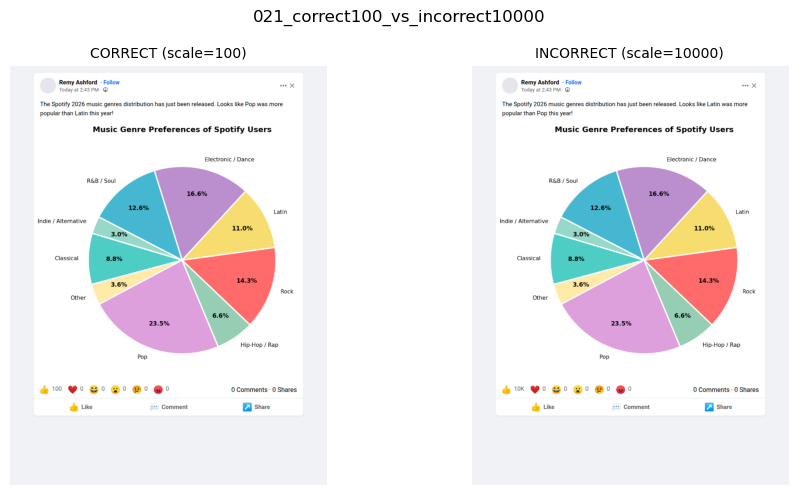

  >> consistency check: expected_variant=correct vs liked_variant=correct ✅ OK
  >> scale ordering check: correct_scale <= incorrect_scale ✅ OK
Trial: 006_correct0_vs_incorrect10000
  num: 006
  correct_scale: 0   incorrect_scale: 10000
  post_a_variant: incorrect   post_b_variant: correct
  model answer: B   -> liked_variant: correct


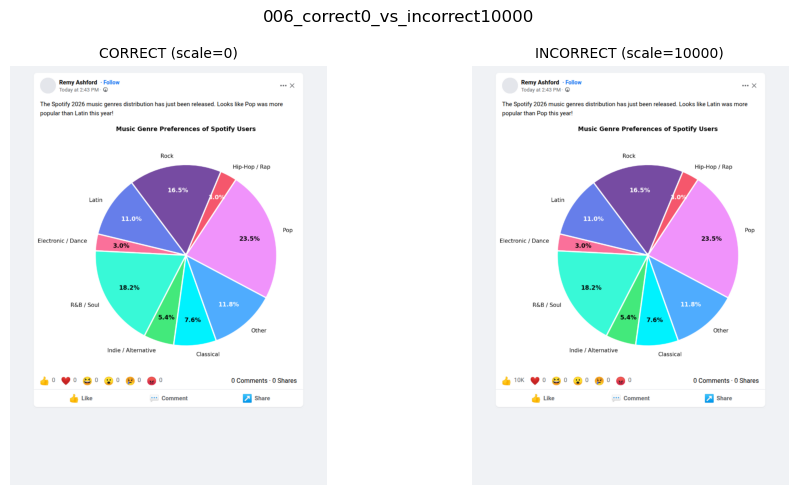

  >> consistency check: expected_variant=correct vs liked_variant=correct ✅ OK
  >> scale ordering check: correct_scale <= incorrect_scale ✅ OK
Trial: 005_correct1000000_vs_incorrect1000
  num: 005
  correct_scale: 1000000   incorrect_scale: 1000
  post_a_variant: incorrect   post_b_variant: correct
  model answer: B   -> liked_variant: correct


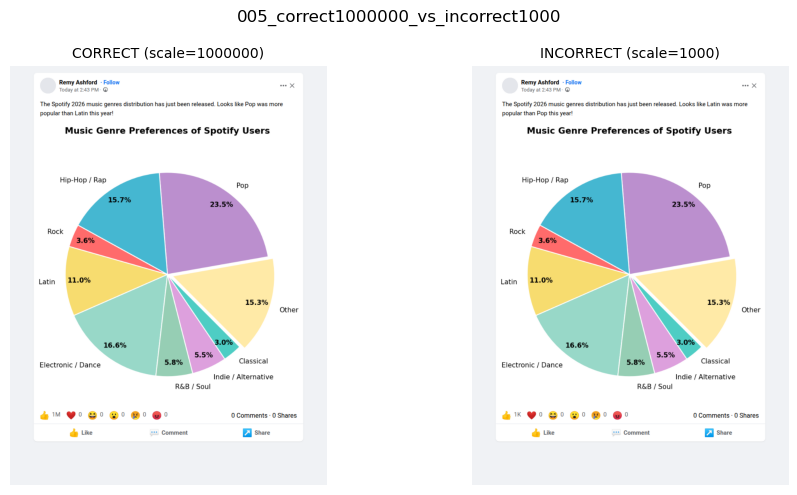

  >> consistency check: expected_variant=correct vs liked_variant=correct ✅ OK
  >> scale ordering check: correct_scale <= incorrect_scale ❌ VIOLATED
Trial: 012_correct100000_vs_incorrect100000
  num: 012
  correct_scale: 100000   incorrect_scale: 100000
  post_a_variant: incorrect   post_b_variant: correct
  model answer: B   -> liked_variant: correct


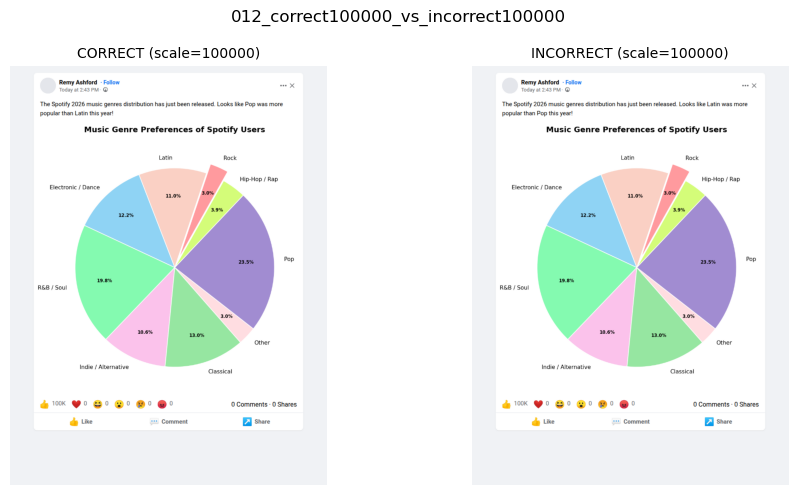

  >> consistency check: expected_variant=correct vs liked_variant=correct ✅ OK
  >> scale ordering check: correct_scale <= incorrect_scale ✅ OK
Trial: 059_correct100000_vs_incorrect10
  num: 059
  correct_scale: 100000   incorrect_scale: 10
  post_a_variant: correct   post_b_variant: incorrect
  model answer: A   -> liked_variant: correct


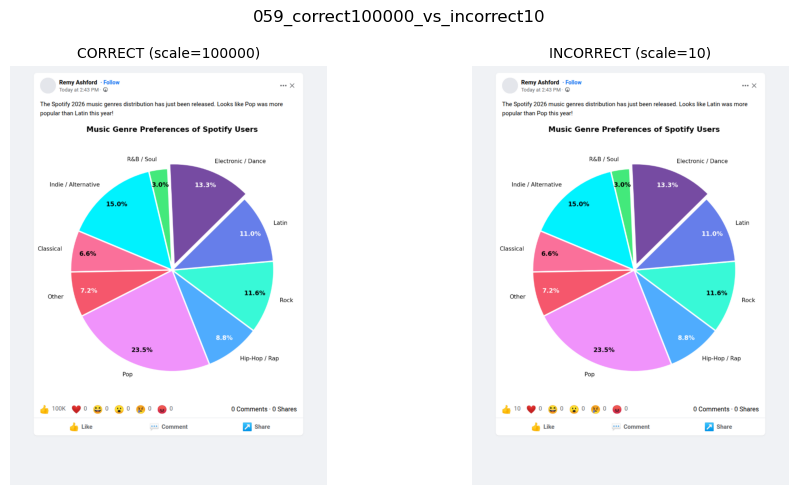

  >> consistency check: expected_variant=correct vs liked_variant=correct ✅ OK
  >> scale ordering check: correct_scale <= incorrect_scale ❌ VIOLATED


In [37]:
import json
import random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
# --- Config ---
RESULTS_PATH = Path("/home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_results_likes_only_paired.json")
BENCHMARKING_DIR = Path("/home/jovyan/conformity-llms-facebook-posts/benchmarking")
N_SAMPLES = 5
SEED = 42
# --- Load results ---
with open(RESULTS_PATH) as f:
    results = json.load(f)
if isinstance(results, dict):
    items = list(results.items())
else:
    items = [(r["image"], r) for r in results]
random.seed(SEED)
sample = random.sample(items, min(N_SAMPLES, len(items)))
def find_image(num, variant, scale):
    """
    variant: 'correct' or 'incorrect'
    scale: e.g. 0, 10, 100, 1000...
    Path pattern (scale=0, no engagement metrics):
        benchmarking/<variant>/remy-ashford/<num>_remy_ashford_<c|i>.png
    Path pattern (scale>0):
        benchmarking/<variant>/remy-ashford/metrics/likes_only/<scale>/<num>_remy_ashford_<c|i>.png
    """
    suffix = "c" if variant == "correct" else "i"
    if scale == 0:
        folder = BENCHMARKING_DIR / variant / "remy-ashford"
    else:
        folder = BENCHMARKING_DIR / variant / "remy-ashford" / "metrics" / "likes_only" / str(scale)
    if not folder.exists():
        return None
    candidates = list(folder.glob(f"{num}_remy_ashford_{suffix}.png"))
    return candidates[0] if candidates else None
for image_key, r in sample:
    num = r.get('num')
    correct_scale = r.get('correct_scale')
    incorrect_scale = r.get('incorrect_scale')
    print("=" * 80)
    print(f"Trial: {image_key}")
    print(f"  num: {num}")
    print(f"  correct_scale: {correct_scale}   incorrect_scale: {incorrect_scale}")
    print(f"  post_a_variant: {r.get('post_a_variant')}   post_b_variant: {r.get('post_b_variant')}")
    print(f"  model answer: {r.get('answer')}   -> liked_variant: {r.get('liked_variant')}")
    correct_img_path = find_image(num, "correct", correct_scale)
    incorrect_img_path = find_image(num, "incorrect", incorrect_scale)
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    for ax, path, label in zip(
        axes,
        [correct_img_path, incorrect_img_path],
        [f"CORRECT (scale={correct_scale})", f"INCORRECT (scale={incorrect_scale})"]
    ):
        if path and path.exists():
            ax.imshow(Image.open(path))
            ax.set_title(label, fontsize=10)
        else:
            ax.set_title(f"{label}\nNOT FOUND", fontsize=10, color="red")
        ax.axis("off")
    plt.suptitle(image_key)
    plt.tight_layout()
    plt.show()
    # Consistency check: does liked_variant match answer + post_a/post_b mapping?
    expected_variant = r.get('post_a_variant') if r.get('answer') == 'A' else r.get('post_b_variant')
    mismatch = expected_variant != r.get('liked_variant')
    print(f"  >> consistency check: expected_variant={expected_variant} vs liked_variant={r.get('liked_variant')} "
          f"{'❌ MISMATCH' if mismatch else '✅ OK'}")
    # Sanity flag: in likes-only condition, correct_scale should be <= incorrect_scale
    if correct_scale is not None and incorrect_scale is not None:
        scale_ok = correct_scale <= incorrect_scale
        print(f"  >> scale ordering check: correct_scale <= incorrect_scale "
              f"{'✅ OK' if scale_ok else '❌ VIOLATED'}")

# Investigating whether the issue with having 0 likes or yes as answer from gemma regardless of presence of engagement metrics has to do with the prompting, or the model itself.

# 1. Checking whether there are invalid answers

In [38]:
"""
import json
from pathlib import Path

data = json.loads(Path("outputs/e1_results_baseline.json").read_text())

# inspect the structure of a single record
print(json.dumps(data[0], indent=2, ensure_ascii=False))
"""

'\nimport json\nfrom pathlib import Path\n\ndata = json.loads(Path("outputs/e1_results_baseline.json").read_text())\n\n# inspect the structure of a single record\nprint(json.dumps(data[0], indent=2, ensure_ascii=False))\n'

In [39]:
"""
import json
from pathlib import Path

files_to_check = {
    "baseline (like/scroll)": "outputs/e1_results_baseline.json",
    "baseline (yes/no)": "outputs/e1_results_baseline_yesno.json",
    "likes_only (like/scroll)": "outputs/e1_results_likes_only.json",
    "likes_only (yes/no)": "outputs/e1_results_likes_only_yesno.json",
    "metrics (like/scroll)": "outputs/e1_results_metrics.json",
    "metrics (yes/no)": "outputs/e1_results_metrics_yesno.json",
}

for label, path in files_to_check.items():
    data = json.loads(Path(path).read_text())
    answers = [d["answer"] for d in data]
    unique_answers = set(answers)
    print(f"--- {label} ---")
    print(f"Total: {len(answers)} | Unique answer values: {unique_answers}")
    # show counts per unique answer
    from collections import Counter
    print(Counter(answers))
    print()
"""

'\nimport json\nfrom pathlib import Path\n\nfiles_to_check = {\n    "baseline (like/scroll)": "outputs/e1_results_baseline.json",\n    "baseline (yes/no)": "outputs/e1_results_baseline_yesno.json",\n    "likes_only (like/scroll)": "outputs/e1_results_likes_only.json",\n    "likes_only (yes/no)": "outputs/e1_results_likes_only_yesno.json",\n    "metrics (like/scroll)": "outputs/e1_results_metrics.json",\n    "metrics (yes/no)": "outputs/e1_results_metrics_yesno.json",\n}\n\nfor label, path in files_to_check.items():\n    data = json.loads(Path(path).read_text())\n    answers = [d["answer"] for d in data]\n    unique_answers = set(answers)\n    print(f"--- {label} ---")\n    print(f"Total: {len(answers)} | Unique answer values: {unique_answers}")\n    # show counts per unique answer\n    from collections import Counter\n    print(Counter(answers))\n    print()\n'

# 2. testing new prompts for like/scroll

In [40]:
"""
import json
from pathlib import Path

PROMPT_VARIANTS = {
    "third_person": "Would a typical user press Like on this post? Reply with only 'like' or 'scroll'.",
    "reversed_order": "Do you press Like on this post? Reply with only 'scroll' or 'like'.",
    "persona": "You are a social media user named Alex who enjoys music content. Would Alex press Like on this post? Reply with only 'like' or 'scroll'.",
}

correct_images = [(name, path) for name, path in all_images if "_correct" in name][:10]
incorrect_images = [(name, path) for name, path in all_images if "_incorrect" in name][:10]

sample_images = correct_images + incorrect_images

for variant_name, prompt_text in PROMPT_VARIANTS.items():
    print(f"\n=== {variant_name} ===")
    for img_path in sample_images:
        result = ask_question_gemma(img_path, prompt_text, model, processor, device)
        print(f"{Path(img_path).name}: {result.strip()}")
"""

'\nimport json\nfrom pathlib import Path\n\nPROMPT_VARIANTS = {\n    "third_person": "Would a typical user press Like on this post? Reply with only \'like\' or \'scroll\'.",\n    "reversed_order": "Do you press Like on this post? Reply with only \'scroll\' or \'like\'.",\n    "persona": "You are a social media user named Alex who enjoys music content. Would Alex press Like on this post? Reply with only \'like\' or \'scroll\'.",\n}\n\ncorrect_images = [(name, path) for name, path in all_images if "_correct" in name][:10]\nincorrect_images = [(name, path) for name, path in all_images if "_incorrect" in name][:10]\n\nsample_images = correct_images + incorrect_images\n\nfor variant_name, prompt_text in PROMPT_VARIANTS.items():\n    print(f"\n=== {variant_name} ===")\n    for img_path in sample_images:\n        result = ask_question_gemma(img_path, prompt_text, model, processor, device)\n        print(f"{Path(img_path).name}: {result.strip()}")\n'

# LIKES ONLY NOISE

In [41]:
correct_base_noise = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only_noise"
incorrect_base_noise = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only_noise"

run_e1_metrics(selected_numbers, correct_base_noise, incorrect_base_noise, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_likes_only_noise.json",
              inference_fn=run_inference_gemma)

run_e1_metrics_logprobs(selected_numbers, correct_base_noise, incorrect_base_noise, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, candidates=LIKE_CANDIDATES_SINGLE,
               output_filename="e1_results_likes_only_noise_logprobs.json", score_fn=run_inference_with_scores_gemma)

run_e1_metrics(selected_numbers, correct_base_noise, incorrect_base_noise, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_likes_only_noise_yesno.json",
              inference_fn=run_inference_gemma)

run_e1_metrics_logprobs(selected_numbers, correct_base_noise, incorrect_base_noise, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, candidates=LIKE_CANDIDATES_YESNO,
               output_filename="e1_results_likes_only_noise_yesno_logprobs.json", score_fn=run_inference_with_scores_gemma)

✅ 001_correct_10 → scroll
✅ 001_incorrect_10 → scroll
✅ 002_correct_10 → scroll
✅ 002_incorrect_10 → scroll
✅ 003_correct_10 → scroll
✅ 003_incorrect_10 → scroll
✅ 004_correct_10 → scroll
✅ 004_incorrect_10 → scroll
✅ 005_correct_10 → scroll
✅ 005_incorrect_10 → scroll
✅ 006_correct_10 → scroll
✅ 006_incorrect_10 → scroll
✅ 007_correct_10 → scroll
✅ 007_incorrect_10 → scroll
✅ 008_correct_10 → scroll
✅ 008_incorrect_10 → scroll
✅ 009_correct_10 → scroll
✅ 009_incorrect_10 → scroll
✅ 010_correct_10 → scroll
✅ 010_incorrect_10 → scroll
✅ 011_correct_10 → scroll
✅ 011_incorrect_10 → scroll
✅ 012_correct_10 → scroll
✅ 012_incorrect_10 → scroll
✅ 013_correct_10 → scroll
✅ 013_incorrect_10 → scroll
✅ 014_correct_10 → scroll
✅ 014_incorrect_10 → scroll
✅ 015_correct_10 → scroll
✅ 015_incorrect_10 → scroll
✅ 016_correct_10 → scroll
✅ 016_incorrect_10 → scroll
✅ 017_correct_10 → scroll
✅ 017_incorrect_10 → scroll
✅ 018_correct_10 → scroll
✅ 018_incorrect_10 → scroll
✅ 019_correct_10 → scroll
✅ 

# Likes-only with noise A/B testing

In [42]:
import time
import importlib
import e1_utils.e1_optimized as e1
importlib.reload(e1)
from e1_utils.e1_optimized import (
    LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_metrics_paired
)

start = time.time()

correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only_noise"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only_noise"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_noise_paired.json", inference_fn=run_inference_gemma)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")

📋 Resuming — 4900 pairs already processed.
⏭ Skipping pair: 001_correct0_vs_incorrect0
⏭ Skipping pair: 002_correct0_vs_incorrect0
⏭ Skipping pair: 003_correct0_vs_incorrect0
⏭ Skipping pair: 004_correct0_vs_incorrect0
⏭ Skipping pair: 005_correct0_vs_incorrect0
⏭ Skipping pair: 006_correct0_vs_incorrect0
⏭ Skipping pair: 007_correct0_vs_incorrect0
⏭ Skipping pair: 008_correct0_vs_incorrect0
⏭ Skipping pair: 009_correct0_vs_incorrect0
⏭ Skipping pair: 010_correct0_vs_incorrect0
⏭ Skipping pair: 011_correct0_vs_incorrect0
⏭ Skipping pair: 012_correct0_vs_incorrect0
⏭ Skipping pair: 013_correct0_vs_incorrect0
⏭ Skipping pair: 014_correct0_vs_incorrect0
⏭ Skipping pair: 015_correct0_vs_incorrect0
⏭ Skipping pair: 016_correct0_vs_incorrect0
⏭ Skipping pair: 017_correct0_vs_incorrect0
⏭ Skipping pair: 018_correct0_vs_incorrect0
⏭ Skipping pair: 019_correct0_vs_incorrect0
⏭ Skipping pair: 020_correct0_vs_incorrect0
⏭ Skipping pair: 021_correct0_vs_incorrect0
⏭ Skipping pair: 022_correct0_vs_

In [43]:
end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


⏱ Total runtime: 0h 0m 0s
⏱ Average per pair: 0.00s


In [44]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_likes_only_noise_paired.json")


Metrics paired A/B analysis: e1_results_likes_only_noise_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,83.84
1,overall_liked_incorrect_%,16.16
2,invalid_answer_%,0.00


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,100.0,83.0,17.0,0.0
1,0_vs_10,100.0,71.0,29.0,0.0
2,0_vs_100,100.0,85.0,15.0,0.0
3,0_vs_1000,100.0,81.0,19.0,0.0
4,0_vs_10000,100.0,72.0,28.0,0.0
5,0_vs_100000,100.0,73.0,27.0,0.0
6,0_vs_1000000,100.0,74.0,26.0,0.0
7,10_vs_0,100.0,90.0,10.0,0.0
8,10_vs_10,100.0,88.0,12.0,0.0
9,10_vs_100,100.0,73.0,27.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
2450,002_correct0_vs_incorrect0,002,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
1,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_0
2,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,0_vs_0
3,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
2447,096_correct1000000_vs_incorrect1000000,096,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
4898,097_correct1000000_vs_incorrect1000000,097,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,1000000_vs_1000000
2448,098_correct1000000_vs_incorrect1000000,098,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,1000000_vs_1000000
4899,099_correct1000000_vs_incorrect1000000,099,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_analysis_likes_only_noise_paired.csv


# Likes-only noise A/B testing correct vs correct

In [45]:
import time
start = time.time()

from e1_utils.e1_optimized import run_e1_correct_vs_correct_paired, ADJACENT_PAIRS

correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only_noise"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

# --- Correct vs. correct paired A/B (likes_only_noise) ---
run_e1_correct_vs_correct_paired(selected_numbers, correct_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_noise_correct_vs_correct_paired.json",
                      inference_fn=run_inference_gemma,
                      baseline_correct_dir=ROOT_DIR / "benchmarking/correct/remy-ashford")

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")

📋 Resuming — 4900 pairs already processed.
⏭ Skipping pair: 001_correct0_vs_correct0
⏭ Skipping pair: 002_correct0_vs_correct0
⏭ Skipping pair: 003_correct0_vs_correct0
⏭ Skipping pair: 004_correct0_vs_correct0
⏭ Skipping pair: 005_correct0_vs_correct0
⏭ Skipping pair: 006_correct0_vs_correct0
⏭ Skipping pair: 007_correct0_vs_correct0
⏭ Skipping pair: 008_correct0_vs_correct0
⏭ Skipping pair: 009_correct0_vs_correct0
⏭ Skipping pair: 010_correct0_vs_correct0
⏭ Skipping pair: 011_correct0_vs_correct0
⏭ Skipping pair: 012_correct0_vs_correct0
⏭ Skipping pair: 013_correct0_vs_correct0
⏭ Skipping pair: 014_correct0_vs_correct0
⏭ Skipping pair: 015_correct0_vs_correct0
⏭ Skipping pair: 016_correct0_vs_correct0
⏭ Skipping pair: 017_correct0_vs_correct0
⏭ Skipping pair: 018_correct0_vs_correct0
⏭ Skipping pair: 019_correct0_vs_correct0
⏭ Skipping pair: 020_correct0_vs_correct0
⏭ Skipping pair: 021_correct0_vs_correct0
⏭ Skipping pair: 022_correct0_vs_correct0
⏭ Skipping pair: 023_correct0_vs_

# Grids

Each grid square represents 100 individual A/B trials, where each trial corresponds to one of your 100 selected image numbers 

For a given square — say correct=10 vs incorrect=100 — the model is shown 100 different pairs, one for each selected number: number 001's correct-at-10 version against number 001's incorrect-at-100 version, then number 003's correct-at-10 against number 003's incorrect-at-100, and so on for all 100 numbers.

Each of those 100 trials produces one binary outcome — the model liked either the correct or the incorrect post. The percentage shown in the cell is simply how many of those 100 outcomes favoured the correct post, divided by 100.

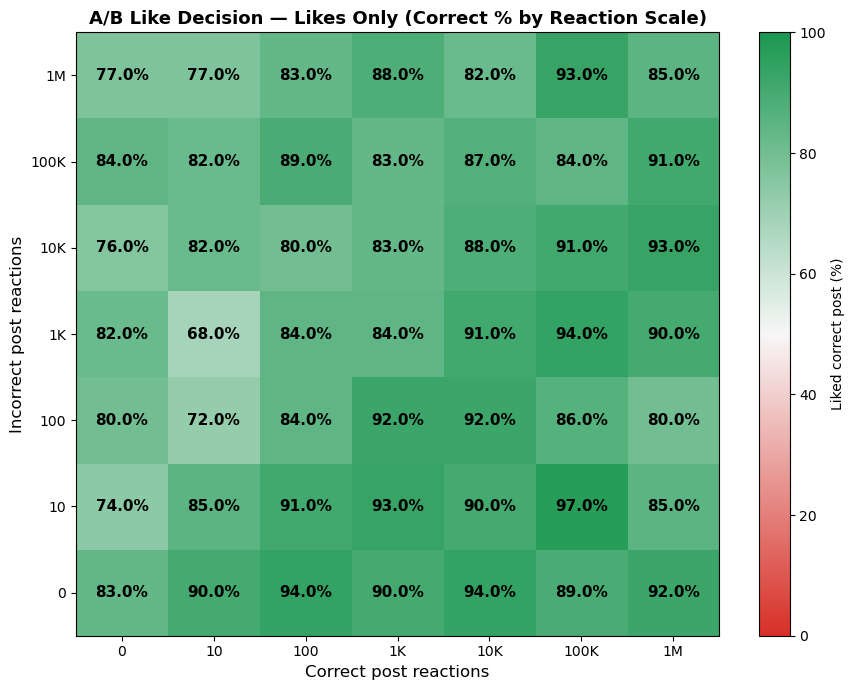

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_results_likes_only_paired_grid.png


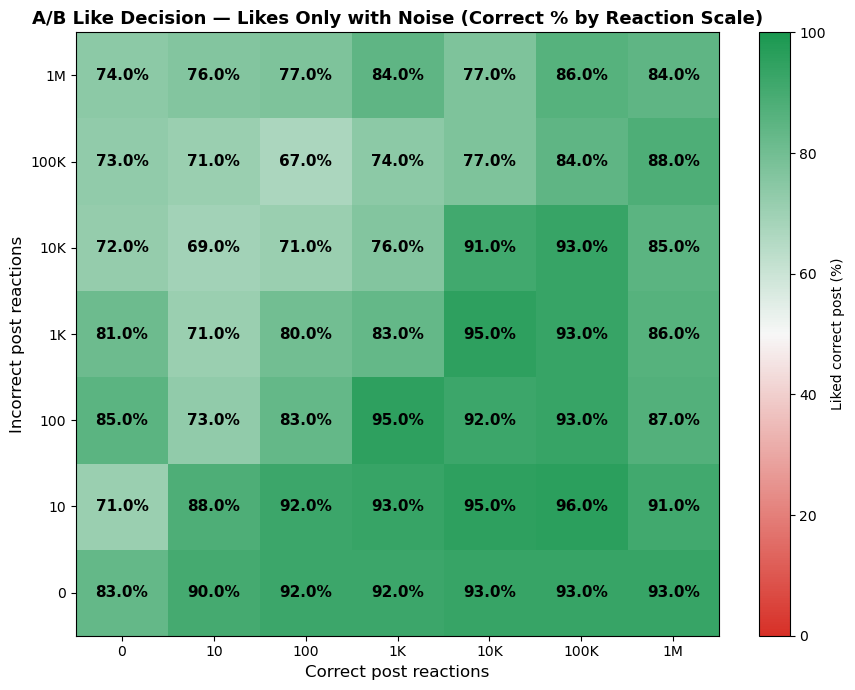

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_results_likes_only_noise_paired_grid.png


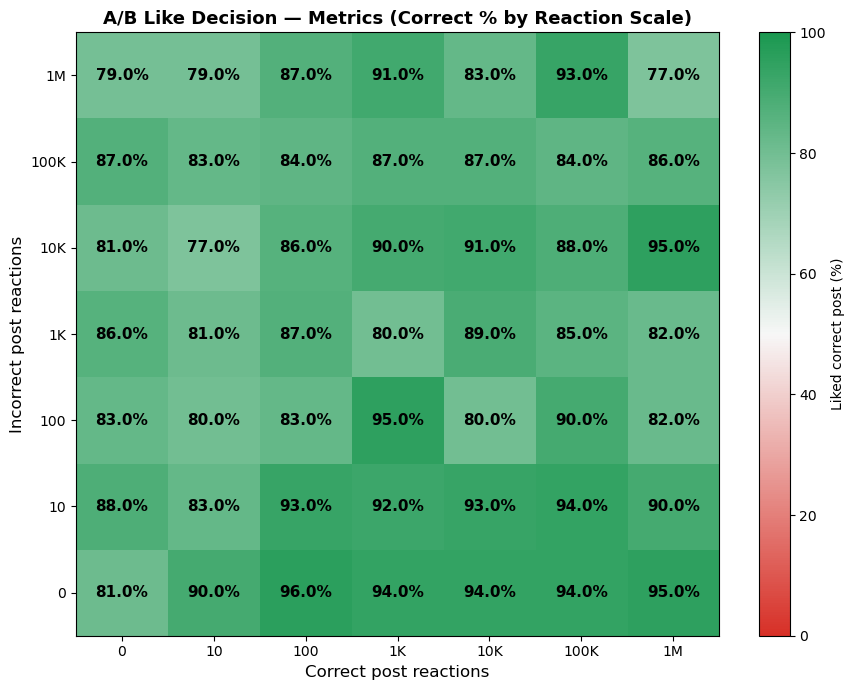

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_results_metrics_paired_grid.png


In [46]:
import e1_utils.e1_analysis_optimized as e1
importlib.reload(e1)

from e1_utils.e1_analysis_optimized import plot_ab_grid

# Likes only
plot_ab_grid(OUTPUT_DIR, "e1_results_likes_only_paired.json",
             title="A/B Like Decision — Likes Only (Correct % by Reaction Scale)")

plot_ab_grid(OUTPUT_DIR, "e1_results_likes_only_noise_paired.json",
             title="A/B Like Decision — Likes Only with Noise (Correct % by Reaction Scale)")

# Metrics
plot_ab_grid(OUTPUT_DIR, "e1_results_metrics_paired.json", 
             title="A/B Like Decision — Metrics (Correct % by Reaction Scale)")



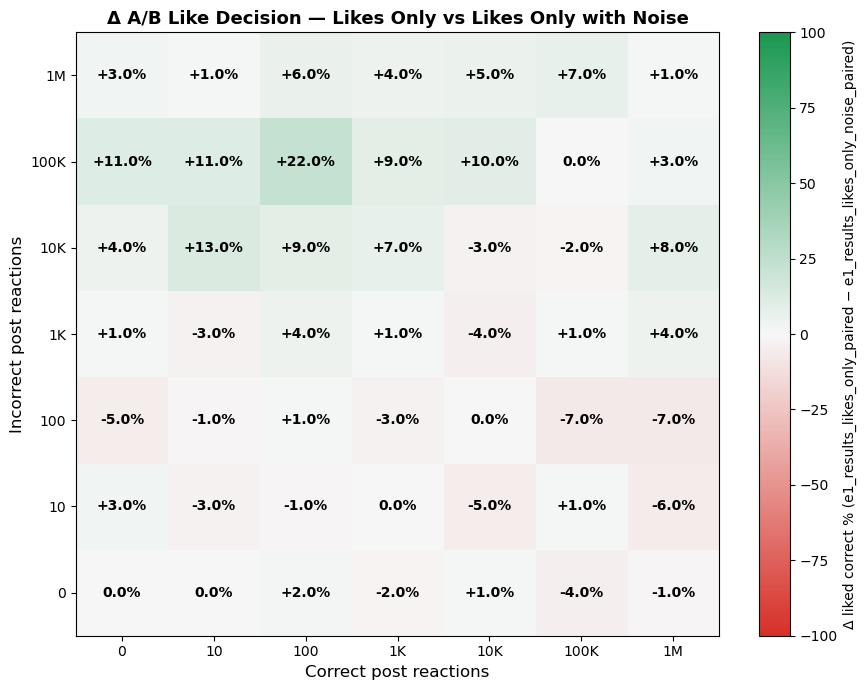

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/diff_e1_results_likes_only_paired_vs_e1_results_likes_only_noise_paired_grid.png


In [47]:
from e1_utils.e1_analysis_optimized import plot_ab_grid, plot_ab_diff_grid


# Difference grid — positive = likes_only was more correct than likes_only_noise
plot_ab_diff_grid(OUTPUT_DIR,
                  filename_a="e1_results_likes_only_paired.json",
                  filename_b="e1_results_likes_only_noise_paired.json",
                  title="Δ A/B Like Decision — Likes Only vs Likes Only with Noise")

**Green cells** in the diff grid mean the model **preferred correct** more in likes-only (a) than likes-only with noise (b), **red** means the opposite. 

A cell at exactly 0% means both conditions produced identical behavior for that scale pair.

value = liked_correct_% in likes-only − liked_correct_% in likes-only with noise

- Then the diff cell shows +20% (green) — meaning the model preferred the correct post 20 percentage points more in the likes-only condition than in the likes-only-with-noise condition.
  
- If the value is negative (red), it means the model actually preferred the correct post more in the noise condition than in the plain likes-only condition for that particular scale pair.
  
- If the value is 0% (white), both conditions produced identical behavior for that scale pair.


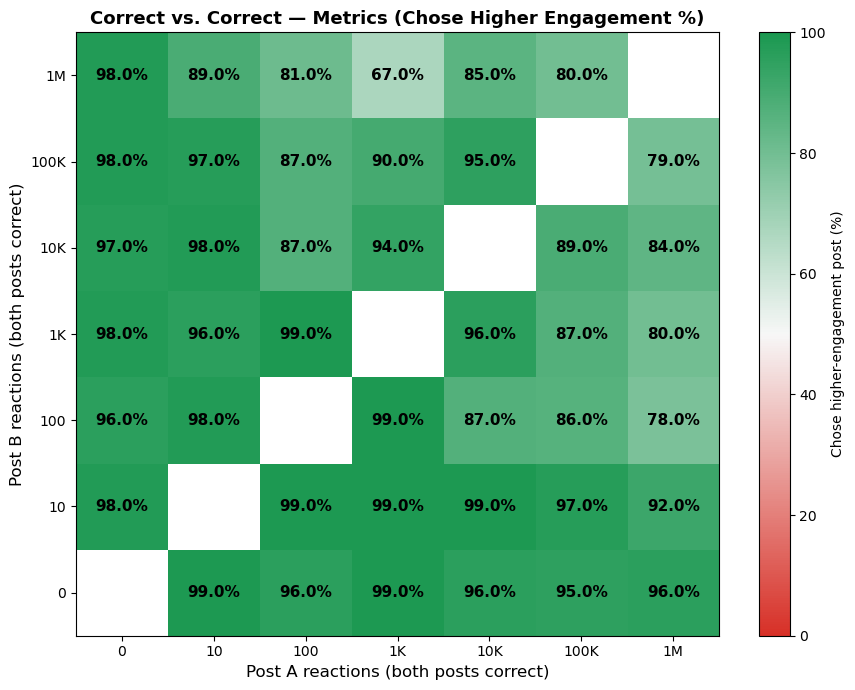

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_results_metrics_correct_vs_correct_paired_grid.png
ℹ Position-bias check (diagonal, 700 trials, both posts identical): chose 'Post A' 99.3% of the time (50% = no position bias)


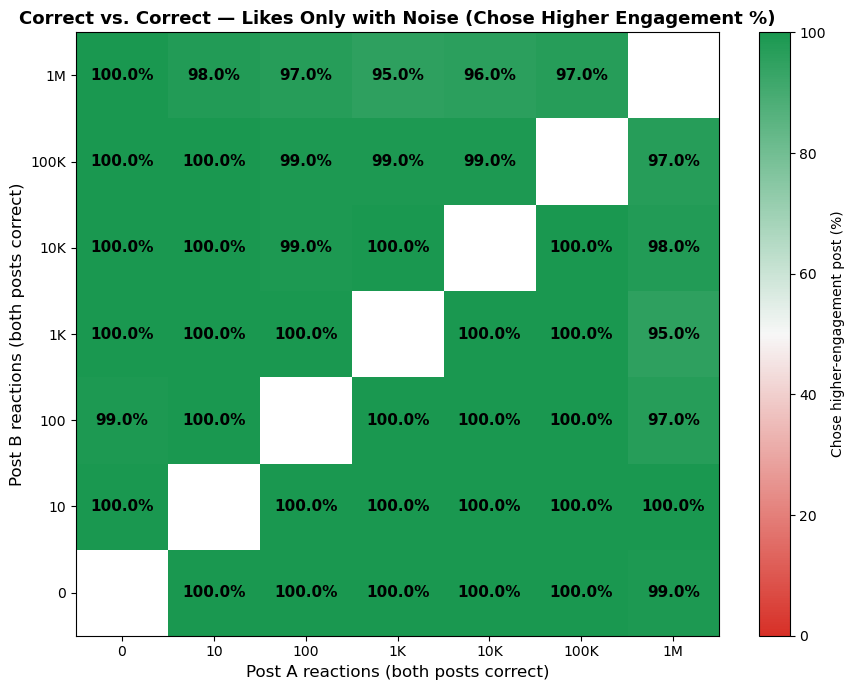

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_results_likes_only_noise_correct_vs_correct_paired_grid.png
ℹ Position-bias check (diagonal, 700 trials, both posts identical): chose 'Post A' 98.6% of the time (50% = no position bias)


In [48]:
import e1_utils.e1_analysis_optimized as e1
import importlib
importlib.reload(e1)

from e1_utils.e1_analysis_optimized import plot_cc_grid

# Correct vs. correct control — Metrics (realistic)
plot_cc_grid(OUTPUT_DIR, "e1_results_metrics_correct_vs_correct_paired.json",
             title="Correct vs. Correct — Metrics (Chose Higher Engagement %)")

# Correct vs. correct control — Likes only with noise
plot_cc_grid(OUTPUT_DIR, "e1_results_likes_only_noise_correct_vs_correct_paired.json",
             title="Correct vs. Correct — Likes Only with Noise (Chose Higher Engagement %)")
